In [1]:
# Define the default font sizes to make the figures prettier:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter, jaxfixedpt
from scipy import signal
import jax
import jax.numpy as jnp

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [2]:
from pathlib import Path
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Optional, Union, Tuple, Dict, Any
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)
_Array = Union[jnp.ndarray]

IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

#### Example 3.9
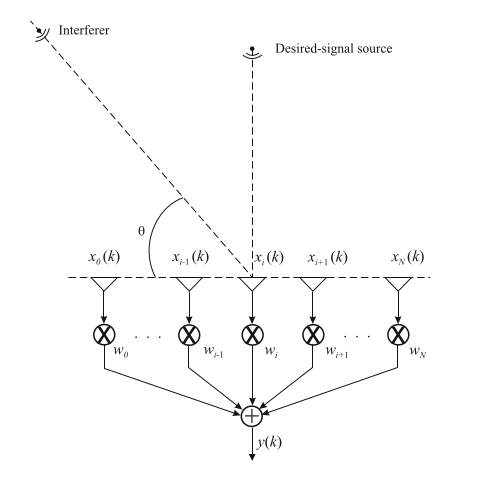

An array of antennas with four elements, with inter-element spacing of $0.15\,\text{m}$, receives signals from two different sources arriving at $90^\circ$ and $30^\circ$ of angles with respect to the axis where the antennas are placed. The desired signal impinges on the antenna at $90^\circ$. The signal of interest is a sinusoid of frequency $20\,\text{MHz}$, and the interferer signal is a sinusoid of frequency $70\,\text{MHz}$. The sampling frequency is $2\,\text{GHz}$.

Use the linearly constrained LMS algorithm in order to adapt the array coefficients.
##### Problem Setup
* Number of antennas: $N = 4$ elements
* Inter-element spacing: $d = 0.15\,\text{m}$
* Desired signal: $20\,\text{MHz at } 90^\circ$
* Interferer: $70\,\text{MHz at } 30^\circ$
* Sampling frequency: $f_s = 2\,\text{GHz}$
* Speed of light: $c = 3 \times 10^8\,\text{m/s}$

Using step size: 0.01 (as in textbook)
Initial weights: [0.25+0.00000000e+00j 0.25-9.61835347e-19j 0.25-1.92367069e-18j
 0.25-2.88550604e-18j]
Initial constraint check C^H w = (1+0j)
Starting adaptation...
Adaptation complete


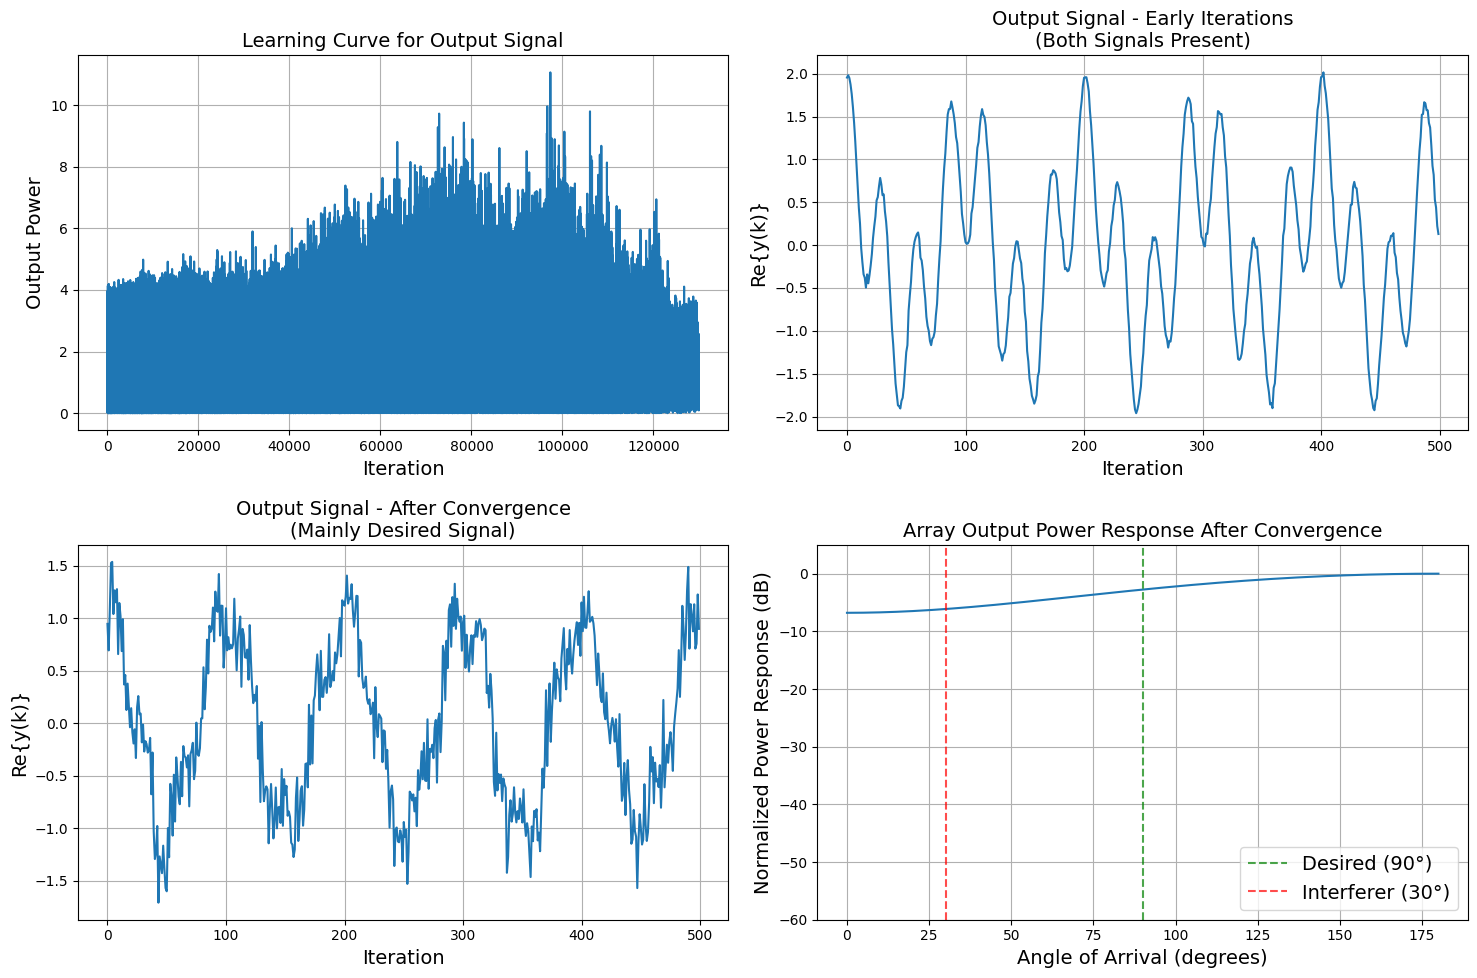


=== PERFORMANCE RESULTS ===
Final desired signal gain (90°): 1.000000
Final interferer gain (30°): 0.026320
Interferer rejection: 15.80 dB
Final output power: 0.815711
Final constraint check C^H w = 1.000000-0.000000j
Null depth at 30°: -6.13 dB
Average output power - initial: 2.028316
Average output power - final: 1.070304
Power reduction: 1.90x


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS (EXACTLY as in Example 3.9)
c = 3e8                      # speed of light (m/s)
Fs = 2e9                     # sampling frequency (Hz)
f_des = 20e6                 # desired freq (Hz) 
f_int = 70e6                 # interferer freq (Hz)
d = 0.15                     # inter-element spacing (m)
N = 4                        # number of antennas
mu = 0.01                    # step size (AS IN TEXTBOOK)
K = 130000                   # number of snapshots
sigma_noise = 0.01           # spatial noise variance

print(f'Using step size: {mu} (as in textbook)')

# steering vector 
def steering_vector(theta_deg, f):
    wavelength = c / f
    theta_rad = np.deg2rad(theta_deg)
    indices = np.arange(N)
    phase = -2 * np.pi / wavelength * indices * d * np.cos(theta_rad)
    return np.exp(1j * phase).reshape((N, 1))

# CONSTRAINT: unit response for 90° at desired frequency
C = steering_vector(90.0, f_des)
f_vec = np.array([1.0])

# INITIALIZATION: w(0) = C(C^T C)^{-1} f (AS IN TEXTBOOK)
CtC_inv = np.linalg.inv(C.conj().T @ C)
w = (C @ CtC_inv @ f_vec).reshape((N,1))  # Initial weights
fc = w.copy()  # Fixed component
P = np.eye(N) - C @ CtC_inv @ C.conj().T  # Projection matrix

print(f"Initial weights: {w.ravel()}")
print(f"Initial constraint check C^H w = {(C.conj().T @ w).item()}")

# Steering vectors
c90 = steering_vector(90.0, f_des)
c30 = steering_vector(30.0, f_int)

# Generate signals (complex sinusoids)
n = np.arange(K)
s_des = np.exp(1j * 2*np.pi*f_des/Fs * n)  # Desired: 20MHz
s_int = np.exp(1j * 2*np.pi*f_int/Fs * n)  # Interferer: 70MHz

# Arrays for results
y_hist = np.zeros(K, dtype=np.complex128)
output_power = np.zeros(K)
rng = np.random.default_rng(42)

print("Starting adaptation...")
for k in range(K):
    # Generate received signal (both desired + interferer + noise)
    noise_vec = np.sqrt(sigma_noise/2) * (rng.standard_normal(N) + 1j*rng.standard_normal(N))
    xk = (c90 * s_des[k] + c30 * s_int[k]).reshape((N,)) + noise_vec
    xk = xk.reshape((N, 1))
    
    # Compute output
    y = (w.conj().T @ xk).item()
    
    # Store results
    y_hist[k] = y
    output_power[k] = np.abs(y)**2
    
    # CONSTRAINED LMS UPDATE (Equation 3.99)
    w = P @ (w - 2 * mu * y * xk) + fc

print("Adaptation complete")

# FINAL WEIGHTS AND BEAM PATTERN
final_w = w.ravel()

# Calculate beam pattern for desired frequency (20MHz)
angles = np.linspace(0, 180, 181)
beam_response = np.zeros_like(angles, dtype=float)

for i, ang in enumerate(angles):
    a_theta = steering_vector(ang, f_des)
    beam_response[i] = np.abs(final_w.conj() @ a_theta.ravel())**2

# NORMALIZE beam pattern to peak = 1 (0 dB)
beam_response_db = 10 * np.log10(beam_response / np.max(beam_response) + 1e-10)

# PLOTS AS IN TEXTBOOK
plt.figure(figsize=(15, 10))

# Figure 1: Learning curve (Output power)
plt.subplot(2, 2, 1)
plt.plot(output_power)
plt.xlabel('Iteration')
plt.ylabel('Output Power')
plt.title('Learning Curve for Output Signal')
plt.grid(True)

# Figure 2: Output signal early iterations (both signals present)
plt.subplot(2, 2, 2)
plt.plot(np.real(y_hist[:500]))
plt.xlabel('Iteration')
plt.ylabel('Re{y(k)}')
plt.title('Output Signal - Early Iterations\n(Both Signals Present)')
plt.grid(True)

# Figure 3: Output signal after convergence (mainly desired)
plt.subplot(2, 2, 3)
plt.plot(np.real(y_hist[-500:]))
plt.xlabel('Iteration') 
plt.ylabel('Re{y(k)}')
plt.title('Output Signal - After Convergence\n(Mainly Desired Signal)')
plt.grid(True)

# Figure 4: Beam pattern after convergence
plt.subplot(2, 2, 4)
plt.plot(angles, beam_response_db)
plt.axvline(x=90, color='green', linestyle='--', alpha=0.7, label='Desired (90°)')
plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Interferer (30°)')
plt.xlabel('Angle of Arrival (degrees)')
plt.ylabel('Normalized Power Response (dB)')
plt.title('Array Output Power Response After Convergence')
plt.ylim([-60, 5])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# PERFORMANCE ANALYSIS
final_desired_gain = np.abs(final_w.conj() @ c90.ravel())**2
final_interferer_gain = np.abs(final_w.conj() @ c30.ravel())**2
rejection_db = 10 * np.log10(final_desired_gain / (final_interferer_gain + 1e-10))

print(f"\n=== PERFORMANCE RESULTS ===")
print(f"Final desired signal gain (90°): {final_desired_gain:.6f}")
print(f"Final interferer gain (30°): {final_interferer_gain:.6f}")
print(f"Interferer rejection: {rejection_db:.2f} dB")
print(f"Final output power: {output_power[-1]:.6f}")
print(f"Final constraint check C^H w = {(C.conj().T @ w).item():.6f}")

# Verify the beam pattern has null at 30°
null_idx = np.argmin(np.abs(angles - 30))
null_depth = beam_response_db[null_idx]
print(f"Null depth at 30°: {null_depth:.2f} dB")

# Show convergence behavior
initial_power = np.mean(output_power[:100])
final_power = np.mean(output_power[-100:])
print(f"Average output power - initial: {initial_power:.6f}")
print(f"Average output power - final: {final_power:.6f}")
print(f"Power reduction: {initial_power/final_power:.2f}x")